# NCI State Cancer Profiles data 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas

In [6]:
#read in data
incd_data = pd.read_csv("state_cancer_profiles_NCI_incd.txt")
incd_data.head()

,County,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1
0,US (SEER+NPCR)(1),0.0,NaN,448.6,448.3,448.9,N/A,N/A,N/A,1821045,falling,-1.0,-1.6,-0.5
1,"Union County, Florida(2)",12125.0,Rural,1215,1144.9,1288.5,N/A,N/A,N/A,237,stable,0.3,-0.6,1.2
2,"Polk County, Texas(7)",48373.0,Rural,683.8,651.9,716.9,N/A,N/A,N/A,440,stable,-1.7,-3.9,0.8
3,"McPherson County, Nebraska(2)",31117.0,Rural,677,377.1,1145.8,N/A,N/A,N/A,4,*,*,*,*
4,"Dewey County, South Dakota(2)",46041.0,Rural,649.8,543.8,769.7,N/A,N/A,N/A,29,stable,1.4,-0.5,3.4


In [12]:
#oops, FIPS needs to be read in as a string to preserve leading zeros
incd_data = pd.read_csv("state_cancer_profiles_NCI_incd.txt", dtype={'FIPS': str})

In [ ]:
print(incd_data.shape)
#print(incd_data.isna().sum())

#looks like the CI*Rank([rank note]), Lower CI (CI*Rank), and Upper CI (CI*Rank) cols have a lot of NaNs, so let's drop those, we won't need them

incd_data = incd_data.drop(columns=["CI*Rank([rank note])", "Upper CI (CI*Rank)", "Lower CI (CI*Rank)"]) 
print(incd_data.shape)
#any others remaining?
print(incd_data.isna().sum())


(3143, 14)
(3143, 11)
County                                                          0
FIPS                                                            0
2023 Rural-Urban Continuum Codes([rural urban note])            0
Age-Adjusted Incidence Rate([rate note]) - cases per 100,000    0
Lower 95% Confidence Interval                                   0
Upper 95% Confidence Interval                                   0
Average Annual Count                                            0
Recent Trend                                                    0
Recent 5-Year Trend ([trend note]) in Incidence Rates           0
Lower 95% Confidence Interval.1                                 0
Upper 95% Confidence Interval.1                                 0
dtype: int64


In [27]:
#some column names are really gnarly and have special chars, so let's rename those to something more manageable
incd_data = incd_data.rename(columns={'Age-Adjusted Incidence Rate([rate note]) - cases per 100,000' : 'Age_Adjusted_Incd_Rate', 
                                      '2023 Rural-Urban Continuum Codes([rural urban note])' : 'Rural_Urban_Code'})


#column data types
print(incd_data.dtypes)

County                                                   object
FIPS                                                     object
Rural_Urban_Code                                         object
Age_Adjusted_Incd_Rate                                   object
Lower 95% Confidence Interval                            object
Upper 95% Confidence Interval                            object
Average Annual Count                                     object
Recent Trend                                             object
Recent 5-Year Trend ([trend note]) in Incidence Rates    object
Lower 95% Confidence Interval.1                          object
Upper 95% Confidence Interval.1                          object
dtype: object


In [28]:
#data types look a bit weird, Age_Adjusted_Incd_Rate should be a float, and FIPS should be a string (we already read it in as a string to preserve leading zeros), so let's convert those
incd_data['Age_Adjusted_Incd_Rate'] = pd.to_numeric(incd_data['Age_Adjusted_Incd_Rate'], errors='coerce')
incd_data['FIPS'] = incd_data['FIPS'].astype(str)



### EDA and Visuals

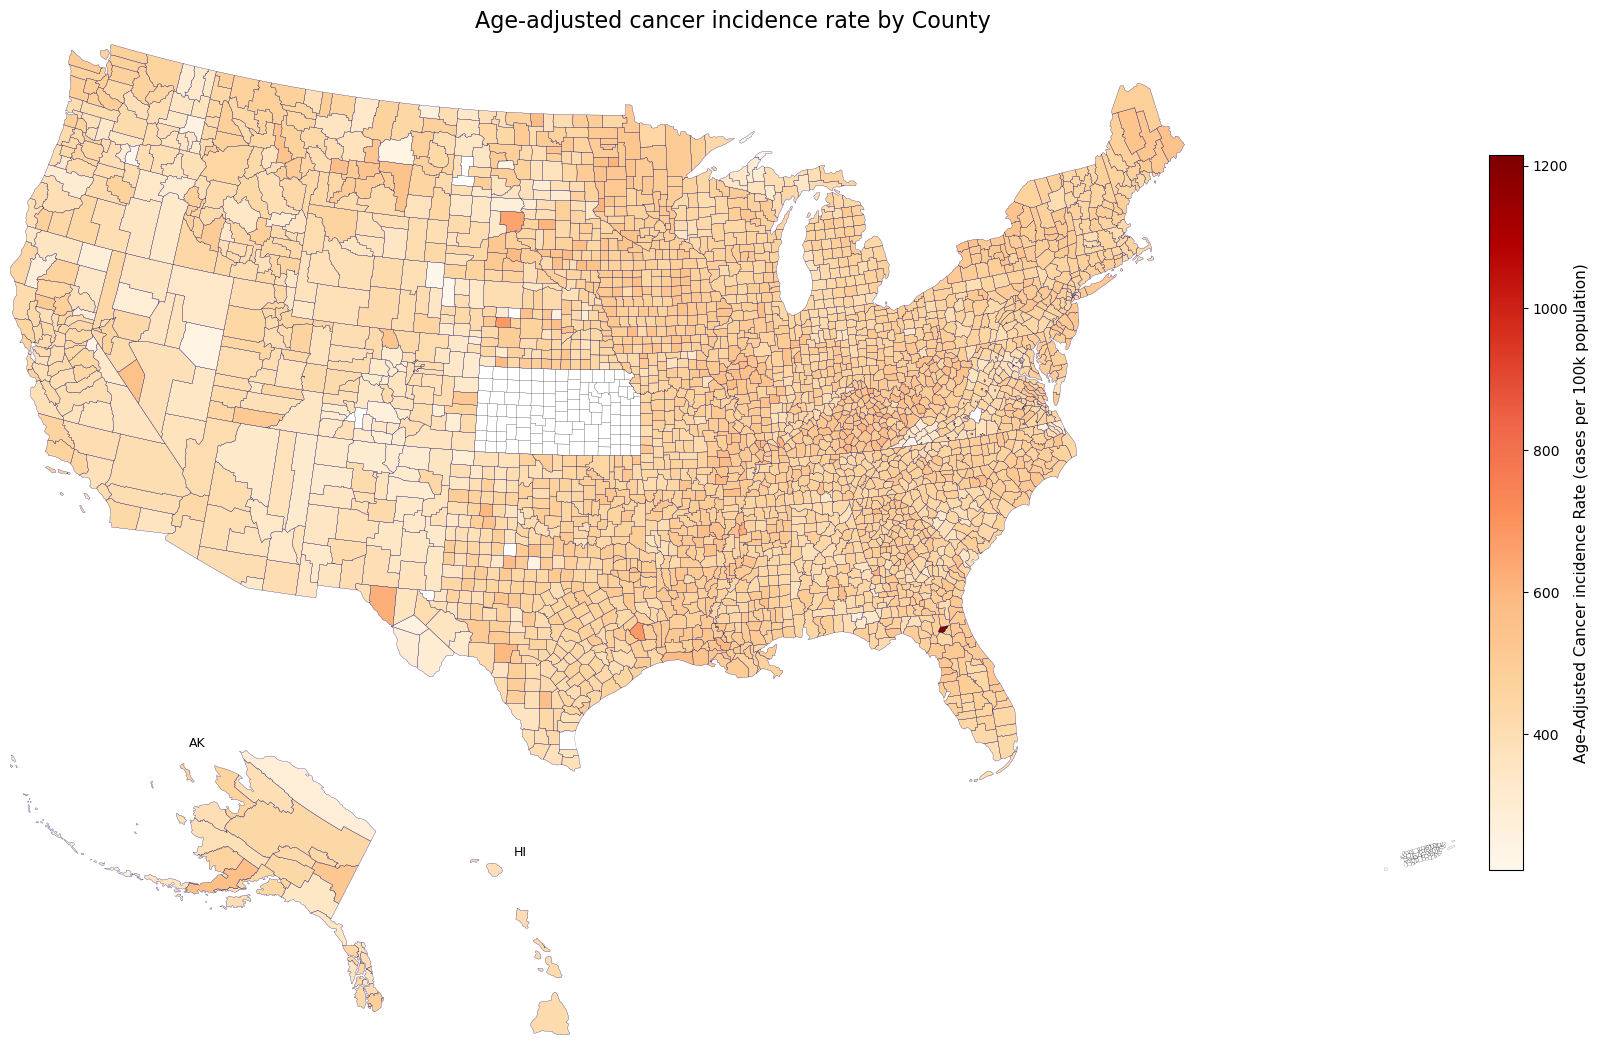

In [37]:
#visualize the Age-Adjusted incidence rate by county (reusing code from the 500_cities_Data notebook for mapping)
#load the shapefile for US counties 
counties = geopandas.read_file("cb_2018_us_county_20m/cb_2018_us_county_20m.shp")

#merge the incidence data with the county shapefile using the FIPS code
merged = counties.merge(incd_data, left_on='GEOID', right_on='FIPS')
#plot the merged data
#reproject map so it takes up the whole figure 
merged = merged.to_crs("EPSG:5070")   
counties = counties.to_crs("EPSG:5070")
conus = merged[~merged['STATEFP'].isin(['02', '15'])]
#use insets for ak and HI
ak = merged[merged['STATEFP'] == '02']
hi = merged[merged['STATEFP'] == '15']
#get bounds of conus for setting main axes limits
conus_bounds = counties[~counties['STATEFP'].isin(['02', '15'])]
ak_bounds  = counties[counties['STATEFP'] == '02']
hi_bounds = counties[counties['STATEFP'] == '15']
#get range for color scale 
vmin = merged['Age_Adjusted_Incd_Rate'].min()
vmax = merged['Age_Adjusted_Incd_Rate'].max()

plot_kwargs = dict(column='Age_Adjusted_Incd_Rate', legend=False,cmap='OrRd', vmin=vmin, vmax=vmax, edgecolor='blue', linewidth=0.1)
fig = plt.figure(figsize=(17, 11))

ax_main = fig.add_axes([0.0, 0.1, 0.85, 0.85])
conus.plot(ax=ax_main, **plot_kwargs)
conus_bounds.plot(ax=ax_main, facecolor="none", edgecolor='black', linewidth=0.1)
ax_main.set_xlim(conus_bounds.total_bounds[[0, 2]])
ax_main.set_ylim(conus_bounds.total_bounds[[1, 3]])
ax_main.set_title('Age-adjusted cancer incidence rate by County', fontsize=16, pad=12)
ax_main.set_axis_off()

ax_ak = fig.add_axes([0.0, 0.0, 0.22, 0.28]) 
ak.plot(ax=ax_ak, **plot_kwargs)
ak_bounds.plot(ax=ax_ak, facecolor="none", edgecolor='black', linewidth=0.1)
ax_ak.set_xlim(ak_bounds.total_bounds[[0, 2]])
ax_ak.set_ylim(ak_bounds.total_bounds[[1, 3]])
ax_ak.set_axis_off()
ax_ak.set_title('AK', fontsize=9, pad=2)

ax_hi = fig.add_axes([0.22, 0.0, 0.16, 0.16])
hi.plot(ax=ax_hi, **plot_kwargs)
hi_bounds.plot(ax=ax_hi, facecolor="none", edgecolor='black', linewidth=0.1)
ax_hi.set_xlim(hi_bounds.total_bounds[[0, 2]])
ax_hi.set_ylim(hi_bounds.total_bounds[[1, 3]])
ax_hi.set_axis_off()
ax_hi.set_title('HI', fontsize=9, pad=2)
sm = plt.cm.ScalarMappable(cmap='OrRd', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.65])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Age-Adjusted Cancer incidence Rate (cases per 100k population)', fontsize=11)

plt.show()

In [40]:
#just curious what the highest and lowest incidence rate counties are
print(incd_data.sort_values('Age_Adjusted_Incd_Rate', ascending=False).head()[['County', 'Age_Adjusted_Incd_Rate']])
print(incd_data.sort_values('Age_Adjusted_Incd_Rate', ascending=True).head()[['County', 'Age_Adjusted_Incd_Rate']])

#what's the avg for rural vs urban counties?
print(incd_data.groupby('Rural_Urban_Code')['Age_Adjusted_Incd_Rate'].mean())


                          County  Age_Adjusted_Incd_Rate
1       Union County, Florida(2)                  1215.0
2          Polk County, Texas(7)                   683.8
3  McPherson County, Nebraska(2)                   677.0
4  Dewey County, South Dakota(2)                   649.8
5    Bracken County, Kentucky(7)                   621.8
                            County  Age_Adjusted_Incd_Rate
3029     Sioux County, Nebraska(2)                   208.8
3028     Gilliam County, Oregon(2)                   216.6
3027   Niobrara County, Wyoming(2)                   217.9
3026  Keweenaw County, Michigan(2)                   225.2
3025  White Pine County, Nevada(2)                   239.9
Rural_Urban_Code
Rural    455.372786
Urban    463.778988
Name: Age_Adjusted_Incd_Rate, dtype: float64


In [41]:
#export cleaned incidence data 

incd_data.to_csv("cleaned_state_cancer_incd_data.csv", index=False)